In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow.parquet as pq
from tqdm import tqdm
from sklearn.metrics import adjusted_rand_score, silhouette_score, mutual_info_score, adjusted_mutual_info_score, normalized_mutual_info_score

import importlib

import global_mapping as gm
import w1_tree as wt
import representation_metrics as rm 
import geotopics_plots as gtp

import plotly.express as px
import plotly.graph_objects as go

import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.patches as patches

PATH = "../data_clean/"

In [2]:
df_country = pd.read_csv("../data/Floriana_country_info.csv")

df_cs = pd.read_csv(PATH+"df_country_subfield_roll_5y.csv", index_col=[0, 1, 2]).dropna(how="all")
df_cs.columns = df_cs.columns.astype(int)

year_list = df_cs.index.get_level_values(1).unique().sort_values().to_list()
country_list = df_cs.index.get_level_values(0).unique().sort_values().to_list()

df_prob = df_cs.div(df_cs.sum(axis=1), axis=0)

df_total = (
    df_cs
    .sum(axis=1)
    .to_frame("total")
    .reset_index()
    .pivot(index=["country", "year"], columns=["mode"])
    .xs("total", axis=1)
    .assign(collab_share = lambda df: df.collaborative / (df.collaborative + df.individual))
)

df_dist = pd.read_csv(PATH+"df_dist_country.csv", index_col=[0, 1, 2])

In [4]:
df_cs = pd.read_csv(PATH+"df_country_subfield.csv", index_col=[0, 1, 2])

In [5]:
(
    df_cs.sum(axis=1)
    .to_frame("total_domestic_articles")
    .groupby(level=[0, 1]).sum()
    .groupby(level=0).sum()
    .sort_values("total_domestic_articles")
    .assign(total_share=lambda df: np.round(df.total_domestic_articles / df.total_domestic_articles.sum(), 2))
)

,total_domestic_articles,total_share
country,,
EH,1.0,0.00
CK,2.0,0.00
TV,31.0,0.00
NU,65.0,0.00
KI,86.0,0.00
...,...,...
JP,4049536.0,0.04
DE,4560825.0,0.05
GB,5466793.0,0.06


In [6]:
df_subfield = (
    pd.read_csv(PATH+"df_topics.csv")
    [["subfield_id", "subfield_name", "field_id", "field_name", "domain_id", "domain_name"]]
    .drop_duplicates()
    .sort_values(["domain_id", "field_id", "subfield_id"])
)

w1_tree = wt.W1Tree(df_subfield[["domain_id", "field_id", "subfield_id"]], weight_base=10.0)

In [7]:
importlib.reload(gm)

<module 'global_mapping' from '/Users/irinavorobeva/Sociology/Geography Topics/geoTopics/irina_clean/global_mapping.py'>

In [8]:
# mode = "collaborative"
mode = "individual"
res = gm.GlobalMapping(df_dist.xs(mode, level=2),
                       df_prob.xs(mode, level=2),
                       df_total[[mode]].rename(columns={mode: "total"}), 
                       w1_tree.dist, lambda df: w1_tree.barycenter(df, init_step_size=0.001), similarity_sigma=0.1)

In [9]:
sigma_list = [0.04, 0.06, 0.08, 0.1, 0.12, 0.14, 0.16, 0.18, 0.2, 0.22, 0.24, 0.26, 0.28, 0.3, 0.32, 0.34, 0.36, 0.38, 0.4, 0.42, 0.44, 0.46, 0.48, 0.5]
sigma_list = np.round(np.logspace(-1.25, -0.2, 40), 3)

In [11]:
df_mapping_list = []
df_ari_list = []
df_modularity_list = []
df_silhouette_list = []
for sigma in tqdm(sigma_list):
    res = gm.GlobalMapping(df_dist.xs(mode, level=2),
                           df_prob.xs(mode, level=2),
                           df_total[[mode]].rename(columns={mode: "total"}), 
                           w1_tree.dist, lambda df: w1_tree.barycenter(df, init_step_size=0.001), similarity_sigma=sigma)
    df_mapping_list.append(res._df_mapping.assign(sigma=sigma))
    # print(res._ari_score_mean)
    df_ari_list.append(res._ari_score_mean)
    df_modularity_list.append(res._modularity)
    df_silhouette_list.append(res._silhouette_score)

100%|██████████| 40/40 [05:14<00:00,  7.86s/it]


In [12]:
threshold_list = pd.DataFrame(df_ari_list, index=sigma_list, columns=year_list).min(axis=0).to_list()

In [13]:
threshold_list = list(np.minimum(threshold_list, 0.9))

In [14]:
df_mapping_sigma = pd.concat(df_mapping_list)

In [15]:
df_modularity = pd.DataFrame(df_modularity_list, index=sigma_list, columns=res._silhouette_score.index).T

In [16]:
df_mapping_sigma_col = (
    df_mapping_sigma
    .pivot(index=["country", "year"], columns="sigma", values="dynamic_cluster")
)

In [17]:
df_sensitivity_list = []
for year in tqdm(year_list):
    for sigma in sigma_list:
        for sigma2 in sigma_list:
            # print(sigma == sigma2, sigma)
            labels1 = df_mapping_sigma_col.xs(year, level=1)[sigma].values
            labels2 = df_mapping_sigma_col.xs(year, level=1)[sigma2].values
            
            # Mutual Information
            mi = mutual_info_score(labels1, labels2)

            # Normalized MI (recommended)
            nmi = normalized_mutual_info_score(labels1, labels2)

            # Adjusted MI (often even better)
            ami = adjusted_mutual_info_score(labels1, labels2)
            ari = adjusted_rand_score(labels1, labels2)

            df_sensitivity_list.append({
                "year": year,
                "sigma1": sigma,
                "sigma2": sigma2,
                "mi": mi,
                "nmi": nmi,
                "ami": ami,
                "ari": ari
            })
        

100%|██████████| 50/50 [01:52<00:00,  2.26s/it]


In [18]:
df_sensitivity = pd.json_normalize(df_sensitivity_list)

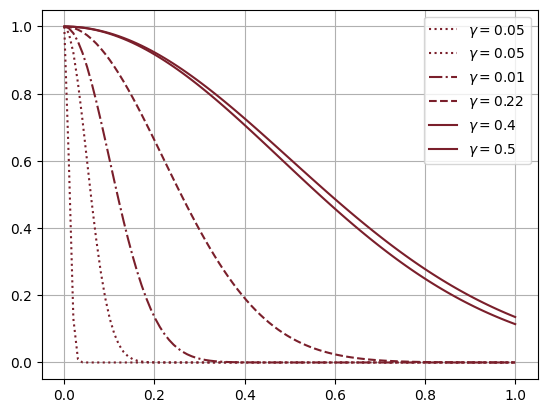

In [19]:
x = np.linspace(0, 1, 100)

plt.plot(x, np.exp(- x ** 2 / (2 * 0.01**2)), color="#7A1F2B", linestyle=":", label=r"$\gamma = 0.05$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.05**2)), color="#7A1F2B", linestyle=":", label=r"$\gamma = 0.05$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.1**2)), color="#7A1F2B", linestyle="-.", label=r"$\gamma = 0.01$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.22**2)), color="#7A1F2B", linestyle="--", label=r"$\gamma = 0.22$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.48**2)), color="#7A1F2B", label=r"$\gamma = 0.4$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.5**2)), color="#7A1F2B", label=r"$\gamma = 0.5$")

plt.legend()
plt.grid()

In [20]:
# plt.figure(figsize=(10,5))

# df_test = (
#     df_dist
#     .xs("individual", level=2)
#     .reset_index()
#     .drop(columns="country")
#     .melt(id_vars="year")
#     .dropna(subset=["value"])
# )

# sns.boxplot(data=df_test, x='year', y='value', order=year_list,
#             color='#7A1F2B', width=0.5, showfliers=True, showmeans=True,
#             meanprops={"marker":"o","markerfacecolor":"white", "markeredgecolor":"black", "markersize":"5"},
#             whiskerprops={"color":"black", "linewidth":0.5},
#             capprops={"color":"black", "linewidth":0},
#             flierprops={"marker":"o", "markerfacecolor":"#7A1F2B", "markeredgecolor":"#7A1F2B", "markersize":2},
#             saturation=0.8)

# # for i in selCountries:
# #     dfTemp = dfEntrW[dfEntrW['country'] == i].sort_values('year').copy()
# #     x_pos = [years.index(y) for y in dfTemp['year']]
# #     plt.plot(x_pos, dfTemp['tree_entropy'],color=colorsCountries[selCountries.index(i)],  label=id2nameC[i], linewidth=4)
    


# plt.legend()
# plt.xticks(rotation=90)
# plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.ylabel('Distance distribution')
# #plt.grid()
# plt.show()

In [21]:
# df_sigma_best.to_csv("df_sigma_best.csv")

In [22]:
# from scipy import ndimage
# import numpy as np

# var = "ari"

# best_sigma_list = []

# for i, year in enumerate(year_list):

#     heatmap_data = (
#         df_sensitivity
#         .query("(year == @year)")
#         .pivot(index="sigma1", columns="sigma2", values=var)
        
#     )
#     threshold = 0.8

#     # binary mask
#     mask = heatmap_data.values > threshold_list[i]
#     # print(year)
#     # print(mask.astype(int))
    

#     # connected components
#     labels, n_components = ndimage.label(mask)

#     # find largest component
#     sizes = ndimage.sum(
#         mask,
#         labels,
#         index=np.arange(1, n_components + 1)
#     )

#     largest_label = np.argmax(sizes) + 1

#     # mask of largest component
#     largest_component = labels == largest_label
#     # print(largest_component.astype(int))
#     # print()


#     # get sigma indices (rows) involved in this component
#     sigma_indices = np.where(largest_component.any(axis=1))[0]

#     # convert indices back to sigma values
#     sigma_values = heatmap_data.index[sigma_indices]
#     sigma = (
#         df_sensitivity
#         .query("(year == @year)")
#         .query("(sigma1 != sigma2) and (sigma1 in @sigma_values) and (sigma2 in @sigma_values)")
#         .groupby(["year", "sigma1"])
#         .agg({"mi": "mean", "ami": "mean", "nmi": "median", "ari": "mean"})
#     ).xs(year).ari.idxmax()
    
#     best_sigma_list.append(sigma)
# df_sigma_best = pd.DataFrame(dict(zip(year_list, best_sigma_list)), index=["sigma"]).T

In [23]:
# df_sigma_best = df_sigma_best.assign(smoothed = lambda df: df.sigma.rolling(3, 0).mean().round(2)).reset_index(names=["year"])

In [35]:
# df_sigma_best.to_csv("df_sigma_best.csv")

In [24]:
# import matplotlib.pyplot as plt

# ami_thresholds = [0.7, 0.8, 0.9]

# plt.figure(figsize=(14, 6))

# for ami_thr in ami_thresholds:

#     df_result = (
#         df_sensitivity.set_index(["year", "sigma1"])
#         # .loc[df_sigma_best.set_index(["year", "sigma"]).index]
#         .query("sigma1 == 0.3")
#         # .query("sigma2 <= 0.5")
#         .query(var+" >= @ami_thr")
#         .groupby("year")
#         .agg(
#             min_sigma2=("sigma2", "min"),
#             max_sigma2=("sigma2", "max")
#         )
#         .reset_index()
#     )

#     plt.fill_between(
#         df_result["year"],
#         df_result["min_sigma2"],
#         df_result["max_sigma2"],
#         alpha=0.1,
#         label=f"AMI ≥ {ami_thr}",
#         color="#7A1F2B"
#     )

# plt.plot(df_sigma_best.year, 0.3*np.ones(len(df_sigma_best.year)), color="#7A1F2B")
# # plt.plot(df_sigma_best.year, df_sigma_best.smoothed, color="#7A1F2B")
# # plt.plot(df_sigma_best.year, df_sigma_best.smoothed, color="#7A1F2B", linestyle="--")

# # plt.yscale("log")
# plt.xlabel("Year", fontsize=16)
# plt.ylabel(r"$\bar\gamma$", fontsize=16)

# # plt.legend(fontsize=14)
# plt.grid(alpha=0.3)
# plt.title(var+" stability range")
# plt.show()

In [26]:
year = 2003

In [27]:
# import matplotlib.pyplot as plt

# heatmap = (
#     df_sensitivity
#     .query("year == @year")
#     .pivot(index="sigma1", columns="sigma2", values=var)
# )

# fig, ax = plt.subplots(figsize=(8, 6))

# im = ax.imshow(
#     heatmap.values,
#     origin="lower",
#     aspect="auto",
#     cmap=cmap,
#     vmin=0
# )

# sigma = df_sigma_best.query("year == @year").sigma.iloc[0]
# sigma_pos = heatmap.index.to_list().index(sigma)

# # Tick labels
# ax.set_xticks(range(len(heatmap.columns)))
# ax.set_xticklabels(np.round(heatmap.columns, 3), rotation=45)

# ax.set_yticks(range(len(heatmap.index)))
# ax.set_yticklabels(np.round(heatmap.index, 3))

# ax.axhline(sigma_pos+0.5, color="white", linewidth=1)
# ax.axhline(sigma_pos-0.5, color="white", linewidth=1)

# ax.axvline(sigma_pos+0.5, color="white", linewidth=1)
# ax.axvline(sigma_pos-0.5, color="white", linewidth=1)
# # ax.axvline(0.2, color="white", linewidth=3, linestyle="--")

# ax.set_xlabel(r"$\sigma_2$", fontsize=14)
# ax.set_ylabel(r"$\sigma_1$", fontsize=14)

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label(var, fontsize=14)

# plt.tight_layout()
# plt.show()

In [28]:
df_n_cluster = (
    df_mapping_sigma_col
    .reset_index()
    .melt(id_vars=["country", "year"], value_name="dyn_cluster")
    # .replace({-1, np.nan})
    .query("dyn_cluster != -1")
    .groupby(["year", "sigma"], as_index=False)
    .dyn_cluster
    .nunique()
    .pivot(index="sigma", columns="year", values="dyn_cluster")
)

In [29]:
df_ari = pd.DataFrame(df_ari_list, index=sigma_list, columns=year_list)

In [30]:
year_list_10y = np.arange(2023, 1974, -5)

In [31]:
year_list_10y
year_list_10y_rev = year_list_10y[::-1]
year_list_10y_rev

array([1978, 1983, 1988, 1993, 1998, 2003, 2008, 2013, 2018, 2023])

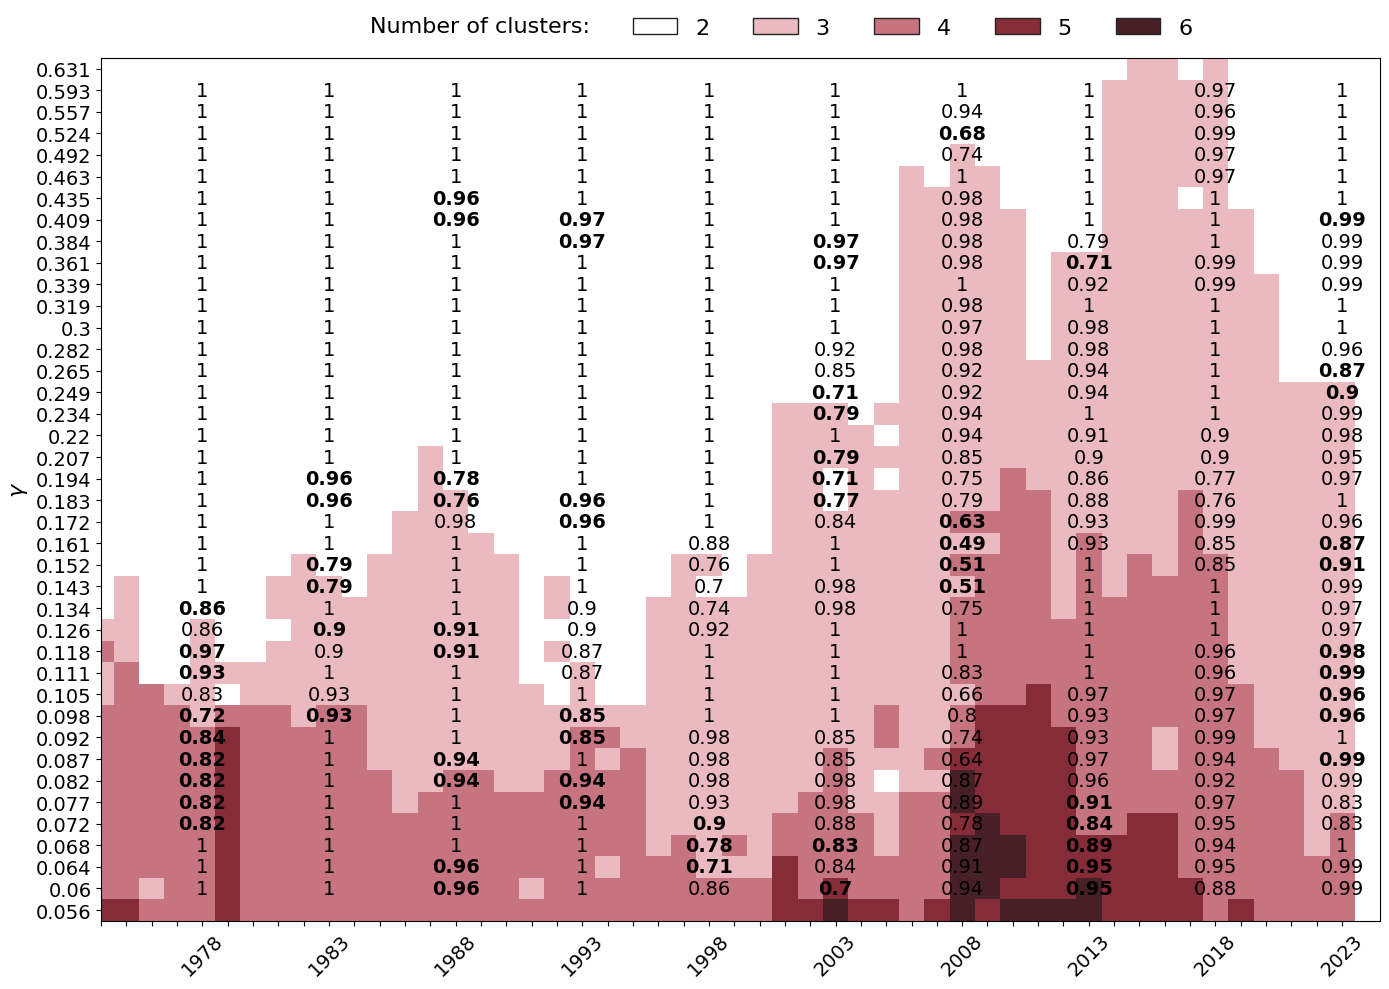

In [161]:
cmap = mcolors.LinearSegmentedColormap.from_list(name="test", colors=[(0, "white"), (0.4, "#E0929C"), (0.8, "#7A1F2B"), (1, "#472025")])

heatmap = df_n_cluster
# [year_list_10y_rev]

fig, ax = plt.subplots(figsize=(14, 10))

im = ax.imshow(
    heatmap.values,
    origin="lower",
    aspect="auto",
    cmap=cmap,
    vmin=2
)

for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        sigma = heatmap.index[i]
        year = heatmap.columns[j]

        if (sigma != sigma_list[-1]) and (sigma != sigma_list[0]) and (year in year_list_10y):
            next_sigma = sigma_list[list(sigma_list).index(sigma)+1]
            prev_sigma = sigma_list[list(sigma_list).index(sigma)-1]

            next_ari = df_sensitivity.set_index(["year", "sigma1", "sigma2"]).loc[(year, sigma, next_sigma)].ari
            prev_ari = df_sensitivity.set_index(["year", "sigma1", "sigma2"]).loc[(year, sigma, prev_sigma)].ari
            label = (next_ari + prev_ari) / 2

            # label = df_sensitivity.set_index(["year", "sigma1", "sigma2"]).loc[(year, sigma, next_sigma)].ari
            # label = df_ari.loc[sigma, year]
            label_check = df_ari.loc[sigma, year]
            # label = df_modularity.loc[year, sigma]

            if label == 1:
                label = 1
            else:
                label = label.round(2)

            # label_check = 0
            # if label_check == 1:
            #     label_check = 1
            # else:
            #     label_check = label_check.round(2)

            if label < label_check:
                ax.text(
                    j, i,
                    label,
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=14,
                    fontweight="bold"
                )
            else:
                ax.text(
                    j, i,
                    label,
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=14
                )

# sigma = df_sigma_best.query("year == @year").sigma.iloc[0]
# sigma_pos = heatmap.index.to_list().index(sigma)

# Tick labels
ax.set_xlim(0, len(year_list)+0.5)
ax.set_xticks(range(len(heatmap.columns)))
x_list = ["" if year not in year_list_10y_rev else year for year in heatmap.columns]
ax.set_xticklabels(x_list, rotation=45, fontsize=14)


ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(np.round(heatmap.index, 3), fontsize=14)


# ax.set_xlabel(r"year", fontsize=16)
ax.set_ylabel(r"$\gamma$", fontsize=16)

# cbar = fig.colorbar(im, ax=ax)
# cbar.set_label("n clusters", fontsize=16)

values = range(2, 7)

colors = cmap(np.linspace(0, 1, len(values)))
legend_elements = [
    Patch(facecolor=colors[i], label=str(v), edgecolor="#242424")
    for i, v in enumerate(values)
]

ax.legend(
    handles=legend_elements,
    title=None,
    bbox_to_anchor=(0.4, 1),
    loc="lower left",
    fontsize=16,
    title_fontsize=14,
    ncol=5,
    # edgecolor="black",
    frameon=False
)

fig.text(
    0.425, 0.978,
    "Number of clusters:",
    ha="right",
    va="top",
    fontsize=16

)
# ax.set_title("Number of clusters")

plt.tight_layout()

fig.savefig(f"../images/heatmap_gamma_v3.jpg", dpi=1000, bbox_inches='tight')

In [33]:
sigma_plot = [0.064, 0.134, 0.3]

In [34]:
import geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(url)

world = world[world['CONTINENT'] != 'Antarctica']

# Convert BOTH to same CRS
world = world.to_crs(epsg=4326)

In [35]:
world.to_csv("world.csv")

In [36]:
import random

my_list = [1, 2, 3, 4, 5]

random.shuffle(my_list)

In [41]:
cmap = mcolors.LinearSegmentedColormap.from_list(
    name="test",
    colors=[
        (0, "white"),
        (0.4, "#E0929C"),
        (0.8, "#7A1F2B"),
        (1, "#472025")
    ]
)

clusters = list(df_mapping_sigma.dynamic_cluster.unique())
random.shuffle(clusters)
colors = cmap(np.linspace(0.15, 1, len(clusters)))

color_dict_tmp = dict(zip(clusters, colors))
color_dict_tmp[-1] = "grey"

In [ ]:
x = np.linspace(0, 1, 100)

plt.plot(x, np.exp(- x ** 2 / (2 * 0.01**2)), color="#7A1F2B", linestyle=":", label=r"$\gamma = 0.05$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.06**2)), color="#7A1F2B", linestyle=":", label=r"$\gamma = 0.05$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.1**2)), color="#7A1F2B", linestyle="-.", label=r"$\gamma = 0.01$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.2**2)), color="#7A1F2B", linestyle="--", label=r"$\gamma = 0.2$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.48**2)), color="#7A1F2B", label=r"$\gamma = 0.4$")
plt.plot(x, np.exp(- x ** 2 / (2 * 0.5**2)), color="#7A1F2B", label=r"$\gamma = 0.5$")

plt.legend()
plt.grid()

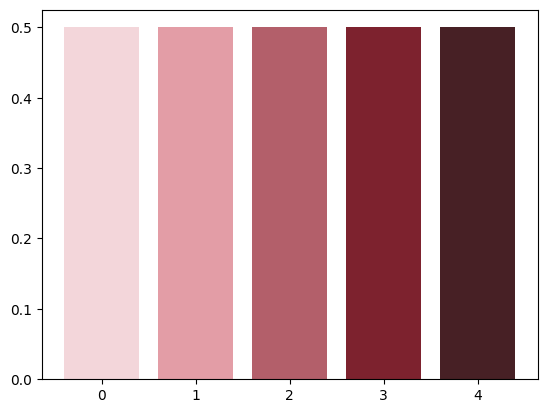

In [55]:
cmap = mcolors.LinearSegmentedColormap.from_list(
    name="test",
    colors=[
        (0, "white"),
        (0.4, "#E0929C"),
        (0.8, "#7A1F2B"),
        (1, "#472025")
    ]
)

colors = cmap(np.linspace(0.15, 1, 5))
for i in range(len(colors)):
    plt.bar(i, 0.5, color=colors[i])

In [115]:
color_dict_params = {
    0.064: {
        -1: "#9D9D9D",
        0: "#203B47",
        4: "#93A6AD",
        5: colors[1],
        6: colors[3]
    },
    0.126: {
        0: "#93A6AD",
        6: colors[1],
        7: "#203B47",
    },
    0.22: {
        0: colors[3],
        2: colors[1],
        3: "#93A6AD"
    },
    0.3: {
        2: "#93A6AD",
        1: colors[3]
    }
}

In [112]:
sf_list = df_subfield.sort_values(["domain_id", "field_id", "subfield_id"]).subfield_id.to_list()

0.064
[4, 5, 6, 0, -1]

0.3
[2, 1]



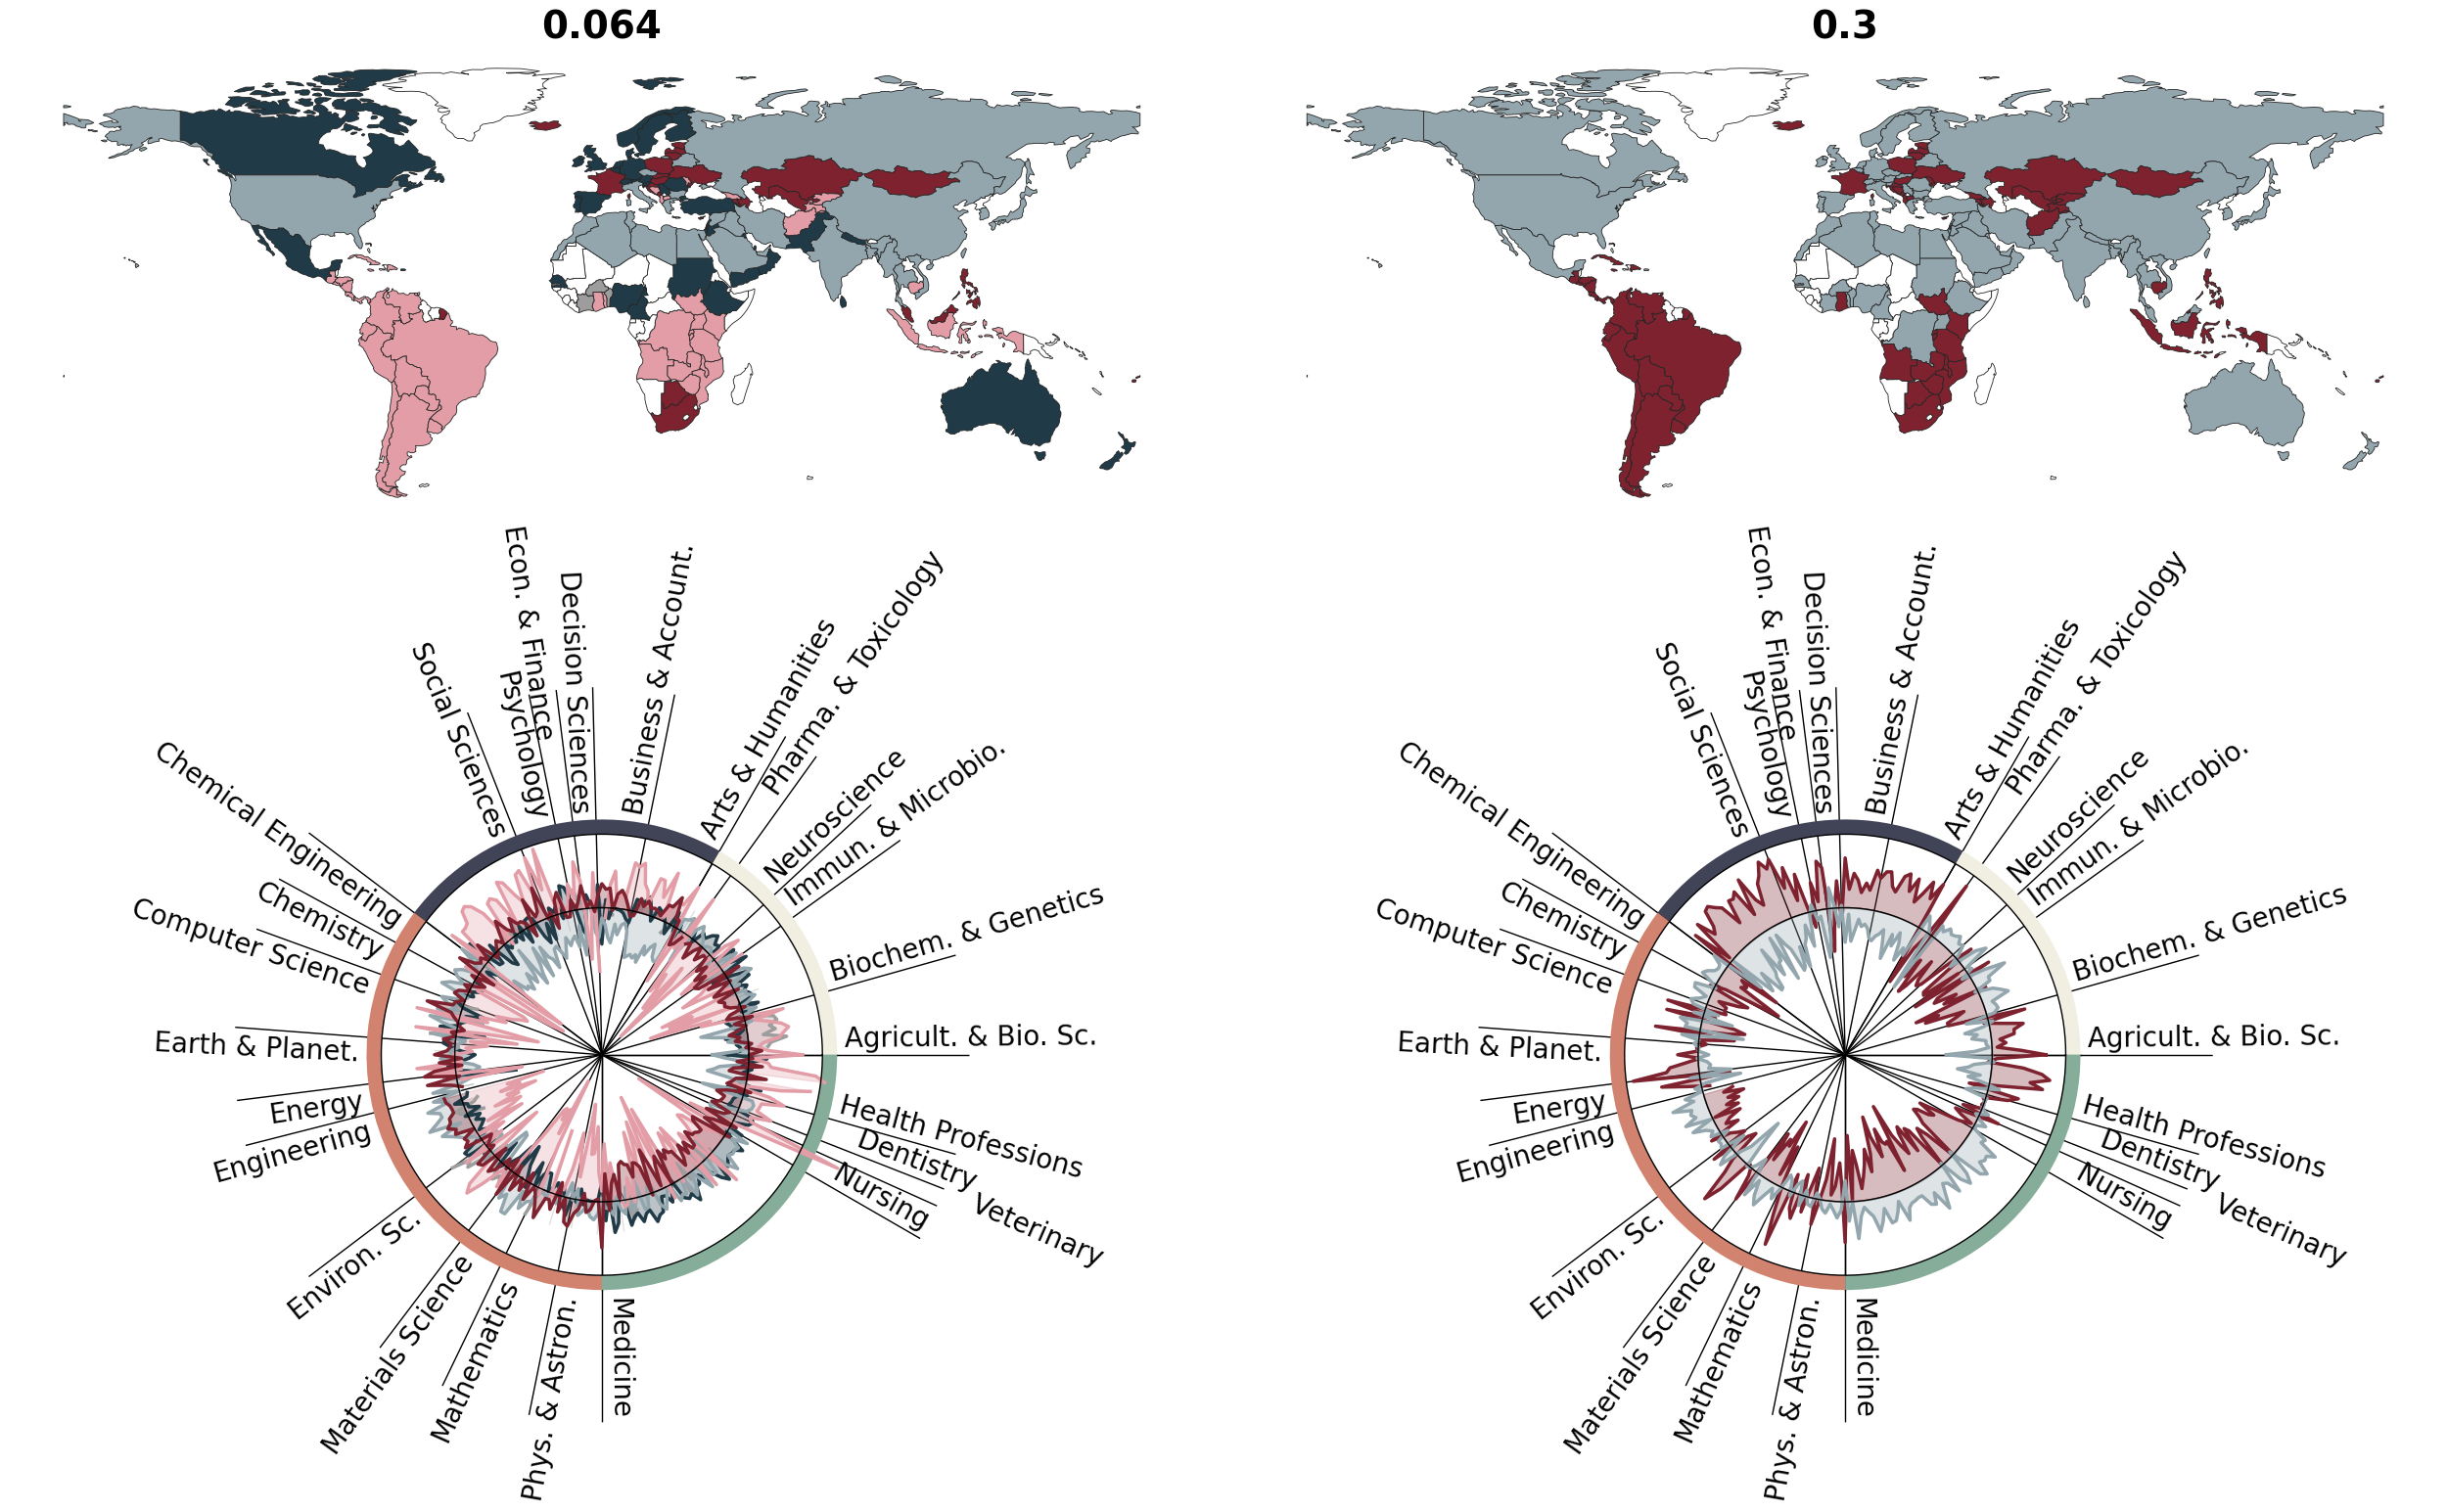

In [158]:
sigma_plot = [0.064, 0.3]

fig = plt.figure(figsize=(32, 20))

base_fontsize=20

outer = fig.add_gridspec(
    2, len(sigma_plot),
    # height_ratios=[1, 1, 1],
    # width_ratios=[1.5, 1],
    hspace=0.05,
    wspace=0.05
)

color_dict_tmp = {-1: "grey", 0: "blue", 1: "red", 4: "green", 5: "brown", 6: "orange", 2: "magenta"}

year = 2023
for i, sigma in enumerate(sigma_plot):

    ax_top = fig.add_subplot(outer[0, i])
    ax_bottom = fig.add_subplot(outer[1, i], projection="polar")

    df_mapping_tmp = df_mapping_sigma_col[sigma].to_frame("dynamic_cluster").xs(year, level=1)
    

    year = 2023
    # --- 4. Merge with world map ---
    world_ = world.merge(
        df_mapping_tmp.merge(df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2"),
        left_on="ISO_A3_EH",
        right_on="alpha-3",
        how="left"
    )

    # --- 5. Map cluster → color ---
    print(sigma)
    print(df_mapping_tmp.dynamic_cluster.drop_duplicates().to_list())
    print()

    if sigma in color_dict_params.keys():
        color_dict_tmp = color_dict_params[sigma]
    else:
        color_dict_tmp = {-1: "grey", 0: "blue", 1: "red", 4: "green", 5: "brown", 6: "orange", 2: "magenta"}
    world_["color"] = world_["dynamic_cluster"].map(color_dict_tmp)

    # fallback for missing
    world_["color"] = world_["color"].fillna("white")

    world_.plot(
        color=world_["color"],
        edgecolor="#242424",
        linewidth=0.6,
        ax=ax_top
    )
    ax_top.set_axis_off()
    ax_top.set_title(sigma, fontsize=28, fontweight="bold")

    df_prob_tmp = (
        df_prob.xs((year, mode), level=(1, 2))
        .merge(df_mapping_tmp, left_index=True, right_index=True, how="right")
        .reset_index()
        .assign(year = year)
        .set_index(["country", "year", "dynamic_cluster"])
    )
    sc = rm.SomeClass(np.log(df_prob_tmp.replace({0: np.nan})))
    sc.get_metric(level_agg = 2, level_norm = 1)
    gtp.draw_polar(ax_bottom, sc._df_metric.xs(year)[sf_list], "", 10,
                   color_dict_tmp)
fig.savefig(f"../images/clusters_gamma_1_v2.jpg", dpi=1000, bbox_inches='tight')

0.126
[7, 6, 0]

0.22
[3, 2, 0]



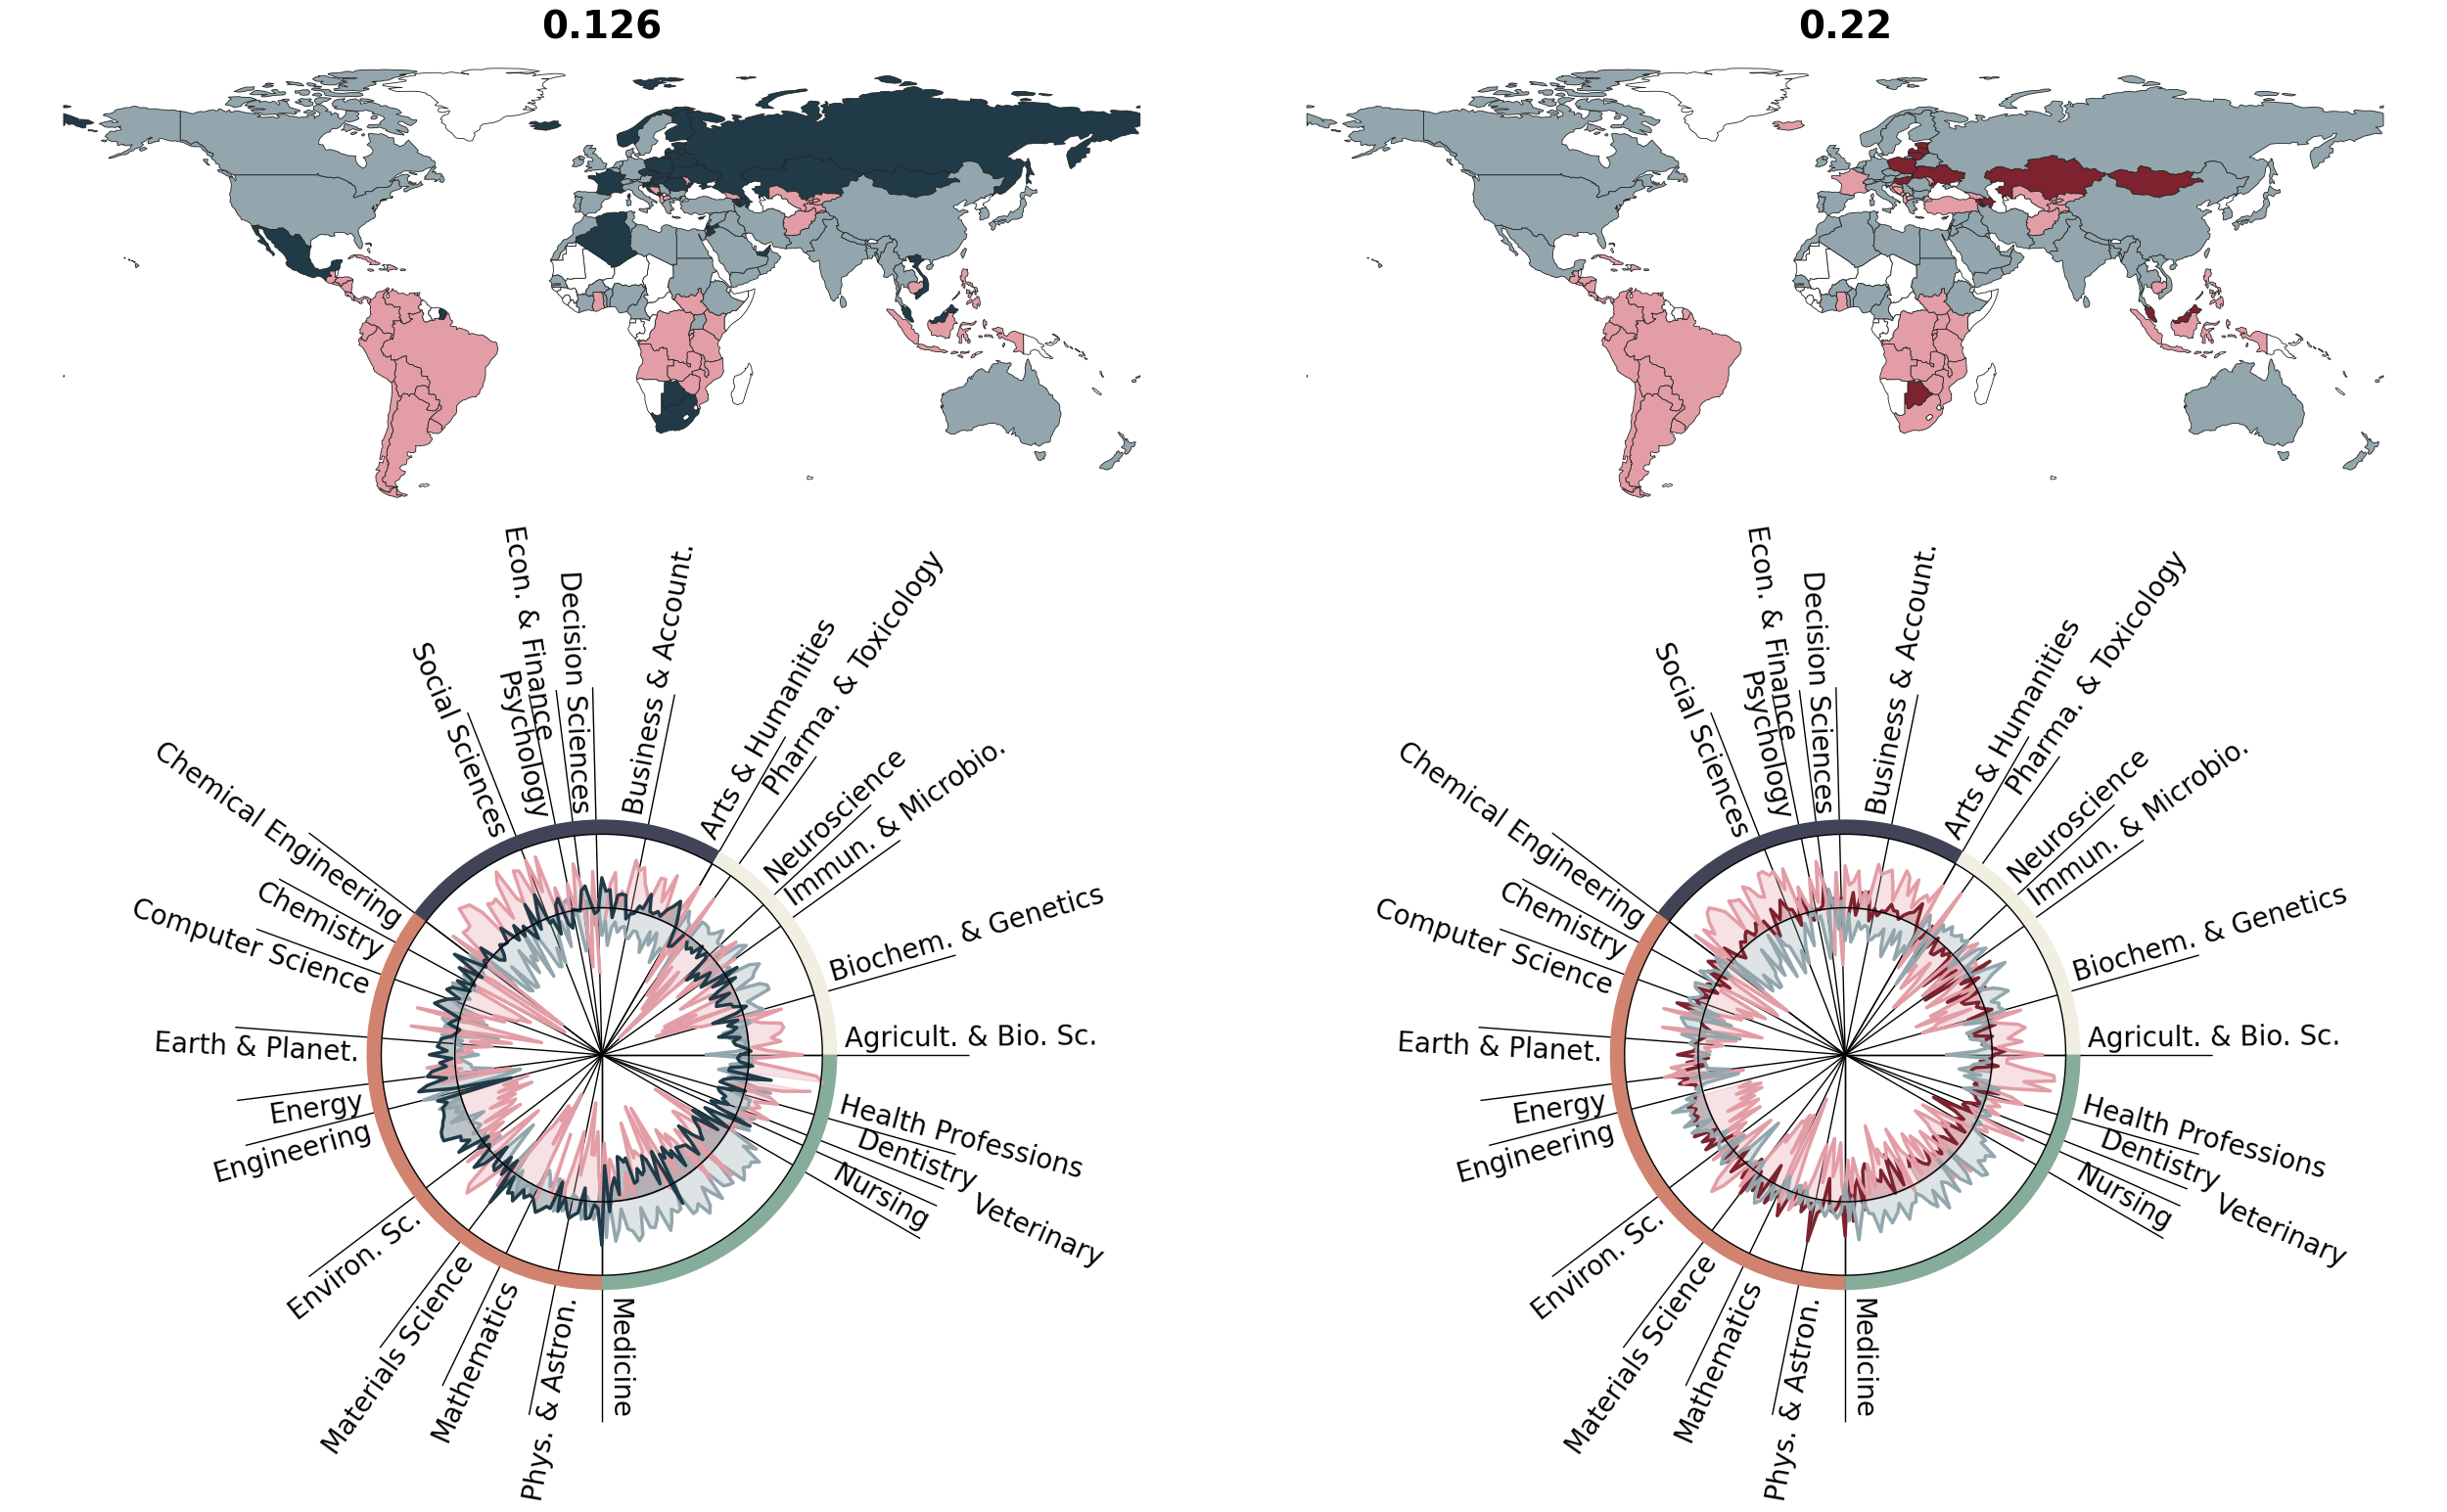

In [ ]:
sigma_plot = [0.126, 0.22]

fig = plt.figure(figsize=(32, 20))

base_fontsize=20

outer = fig.add_gridspec(
    2, len(sigma_plot),
    # height_ratios=[1, 1, 1],
    # width_ratios=[1.5, 1],
    hspace=0.05,
    wspace=0.05
)

color_dict_tmp = {-1: "grey", 0: "blue", 1: "red", 4: "green", 5: "brown", 6: "orange", 2: "magenta", 7: "cyan", 3: "yellow"}

year = 2023
for i, sigma in enumerate(sigma_plot):

    ax_top = fig.add_subplot(outer[0, i])
    ax_bottom = fig.add_subplot(outer[1, i], projection="polar")

    df_mapping_tmp = df_mapping_sigma_col[sigma].to_frame("dynamic_cluster").xs(year, level=1)

    year = 2023
    # --- 4. Merge with world map ---
    world_ = world.merge(
        df_mapping_tmp.merge(df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2"),
        left_on="ISO_A3_EH",
        right_on="alpha-3",
        how="left"
    )


    if sigma in color_dict_params.keys():
        color_dict_tmp = color_dict_params[sigma]
    else:
        color_dict_tmp = color_dict_tmp = {-1: "grey", 0: "blue", 1: "red", 4: "green", 5: "brown", 6: "orange", 2: "magenta", 7: "cyan", 3: "yellow"}

    world_["color"] = world_["dynamic_cluster"].map(color_dict_tmp)

    # fallback for missing
    world_["color"] = world_["color"].fillna("white")

    world_.plot(
        color=world_["color"],
        edgecolor="#242424",
        linewidth=0.6,
        ax=ax_top
    )
    ax_top.set_axis_off()
    ax_top.set_title(sigma, fontsize=28, fontweight="bold")

    df_prob_tmp = (
        df_prob.xs((year, mode), level=(1, 2))
        .merge(df_mapping_tmp, left_index=True, right_index=True, how="right")
        .reset_index()
        .assign(year = year)
        .set_index(["country", "year", "dynamic_cluster"])
    )
    sc = rm.SomeClass(np.log(df_prob_tmp.replace({0: np.nan})))
    sc.get_metric(level_agg = 2, level_norm = 1)
    gtp.draw_polar(ax_bottom, sc._df_metric.xs(year)[sf_list], "", 10,
                   color_dict_tmp)
fig.savefig(f"../images/clusters_gamma_2_v2.jpg", dpi=1000, bbox_inches='tight')

In [108]:
# sigma_plot = [0.087, 0.134, 0.3]

# fig = plt.figure(figsize=(32, 48))

# base_fontsize=20

# outer = fig.add_gridspec(
#     len(sigma_plot), 2,
#     height_ratios=[1, 1, 1],
#     width_ratios=[1.5, 1],
#     hspace=0.05,
#     wspace=0.05
# )

# # color_dict_tmp = {-1: "grey", 0: "blue", 1: "red", 4: "green", 5: "brown", 6: "orange", 2: "magenta"}

# year = 2023
# for i, sigma in enumerate(sigma_plot):

#     ax_left = fig.add_subplot(outer[i, 0])
#     ax_right = fig.add_subplot(outer[i, 1], projection="polar")

#     df_mapping_tmp = df_mapping_sigma_col[sigma].to_frame("dynamic_cluster").xs(year, level=1)

#     year = 2023
#     # --- 4. Merge with world map ---
#     world_ = world.merge(
#         df_mapping_tmp.merge(df_country[["alpha-2", "alpha-3"]], left_index=True, right_on="alpha-2"),
#         left_on="ISO_A3_EH",
#         right_on="alpha-3",
#         how="left"
#     )

#     # --- 5. Map cluster → color ---
#     world_["color"] = world_["dynamic_cluster"].map(color_dict_tmp)

#     # fallback for missing
#     world_["color"] = world_["color"].fillna("white")

#     world_.plot(
#         color=world_["color"],
#         edgecolor="#242424",
#         linewidth=0.6,
#         ax=ax_left
#     )
#     ax_left.set_axis_off()

#     df_prob_tmp = (
#         df_prob.xs((year, mode), level=(1, 2))
#         .merge(df_mapping_tmp, left_index=True, right_index=True, how="right")
#         .reset_index()
#         .assign(year = year)
#         .set_index(["country", "year", "dynamic_cluster"])
#     )
#     sc = rm.SomeClass(np.log(df_prob_tmp.replace({0: np.nan})))
#     sc.get_metric(level_agg = 2, level_norm = 1)
#     display(sc._df_metric)
#     gtp.draw_polar(ax_right, sc._df_metric.xs(year)[sf_list], sigma, 10,
#                    color_dict_tmp)